In [1]:
import torch
import matplotlib.pyplot as plt
import sys, os
sys.path.append('../')
from dinov2.models.vision_transformer import vit_large
import yaml


/nfs/data/1/rrazakami/work/dinov2ForLArTPC/tests/../dinov2/layers/swiglu_ffn.py:43: UserWarning: xFormers is available (SwiGLU)
  warnings.warn("xFormers is available (SwiGLU)")
/nfs/data/1/rrazakami/work/dinov2ForLArTPC/tests/../dinov2/layers/attention.py:27: UserWarning: xFormers is available (Attention)
  warnings.warn("xFormers is available (Attention)")
/nfs/data/1/rrazakami/work/dinov2ForLArTPC/tests/../dinov2/layers/block.py:33: UserWarning: xFormers is available (Block)
  warnings.warn("xFormers is available (Block)")


### Load the student model from the config and checkpoint files

In [3]:
path_to_config = '../out_cvn_memlite/config.yaml'
with open(path_to_config, 'r') as f:
    config = yaml.safe_load(f)

In [4]:
config['student']

{'arch': 'vit_large',
 'patch_size': 16,
 'drop_path_rate': 0.3,
 'layerscale': 1e-05,
 'drop_path_uniform': True,
 'pretrained_weights': '',
 'ffn_layer': 'mlp',
 'block_chunks': 4,
 'qkv_bias': True,
 'proj_bias': True,
 'ffn_bias': True,
 'num_register_tokens': 0,
 'interpolate_antialias': False,
 'interpolate_offset': 0.1}

In [5]:
student_model = vit_large(
    patch_size=config['student']['patch_size'],
    drop_path_rate=config['student']['drop_path_rate'],
    init_values=config['student']['layerscale'],
    drop_path_uniform=config['student']['drop_path_uniform'],
    block_chunks=config['student']['block_chunks'],
    ffn_layer=config['student']['ffn_layer'],
    interpolate_offset=config['student']['interpolate_offset']
)

In [57]:
checkpoint = torch.load('../out_cvn_memlite_1GPU/model_final.rank_0.pth', map_location='cpu')
state_dict = checkpoint['model']
new_state_dict = {
    k.replace('student.backbone.', ''): v 
    for k, v in state_dict.items() 
    if k.startswith('student.backbone.')
}

In [58]:
new_state_dict

{'cls_token': tensor([[[-0.0060, -0.0065,  0.0050,  ..., -0.0023,  0.0039, -0.0023]]]),
 'pos_embed': tensor([[[-0.0157, -0.0274,  0.0405,  ..., -0.0151,  0.0065, -0.0074],
          [ 0.0074, -0.0077,  0.0098,  ..., -0.0166,  0.0131,  0.0209],
          [-0.0040,  0.0197,  0.0009,  ...,  0.0057,  0.0171,  0.0344],
          ...,
          [-0.0250,  0.0134,  0.0160,  ..., -0.0006,  0.0102, -0.0295],
          [ 0.0097, -0.0244,  0.0015,  ..., -0.0202, -0.0088,  0.0365],
          [-0.0063, -0.0012, -0.0031,  ..., -0.0073,  0.0152,  0.0190]]]),
 'mask_token': tensor([[ 0.0017,  0.0013, -0.0009,  ...,  0.0003,  0.0012, -0.0016]]),
 'patch_embed.proj.weight': tensor([[[[ 2.9525e-02, -2.1937e-02, -1.0018e-02,  ..., -3.0794e-02,
            -9.5782e-03, -2.0134e-02],
           [ 2.5846e-02,  1.5702e-02, -5.5941e-03,  ...,  1.1686e-03,
            -3.2077e-02, -8.1039e-03],
           [-2.9295e-02,  1.0241e-02, -1.3920e-03,  ...,  1.9021e-02,
            -1.7742e-02,  3.4369e-02],
        

In [59]:
student_model.load_state_dict(new_state_dict)

<All keys matched successfully>

In [60]:
student_model

DinoVisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (blocks): ModuleList(
    (0): BlockChunk(
      (0-5): 6 x NestedTensorBlock(
        (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
        (attn): MemEffAttention(
          (qkv): Linear(in_features=1024, out_features=3072, bias=True)
          (proj): Linear(in_features=1024, out_features=1024, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): LayerScale()
        (drop_path1): DropPath()
        (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=1024, out_features=4096, bias=True)
          (act): GELU(approximate='none')
          (fc2): Linear(in_features=4096, out_features=1024, bias=True)
          (drop): Dropout(p=0.0, inplace=False)
        )
        (ls2): LayerScale()
        (drop_path2): DropPath()
  

In [61]:
student_model.blocks

ModuleList(
  (0): BlockChunk(
    (0-5): 6 x NestedTensorBlock(
      (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
      (attn): MemEffAttention(
        (qkv): Linear(in_features=1024, out_features=3072, bias=True)
        (proj): Linear(in_features=1024, out_features=1024, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (drop_path1): DropPath()
      (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=1024, out_features=4096, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=4096, out_features=1024, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
      (ls2): LayerScale()
      (drop_path2): DropPath()
    )
  )
  (1): BlockChunk(
    (0-5): 6 x Identity()
    (6-11): 6 x NestedTensorBlock(
      (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
      (attn): MemEffAttention(
       

In [86]:
attention_maps = {}
def get_attention_hook(name):
    def hook(module, input, output):
        print(f'Hook called for {name}, output type {type(output)}')
        print(f'Output shape: {output.shape}')
        attention_maps[name] = output
    return hook

for name, module in student_model.named_modules():
    if module.__class__.__name__ == 'MemEffAttention':
        # print(name, module)
        module.register_forward_hook(get_attention_hook(name))
print(f"\nHooks registered. Now running forward pass...")
print(f"attention_maps before forward: {len(attention_maps)} items")


Hooks registered. Now running forward pass...
attention_maps before forward: 0 items


In [100]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Get features from different layers
first_layer = attention_maps['block_0']  # Early layer
last_layer = list(attention_maps.values())[-1]  # Last layer

# Remove batch dimension
first_features = first_layer[0]  # [197, 1024]
last_features = last_layer[0]   # [197, 1024]

print(f"First layer features shape: {first_features.shape}")
print(f"Last layer features shape: {last_features.shape}")

# Separate CLS token and patch tokens
first_cls = first_features[0]      # [1024]
first_patches = first_features[1:]  # [196, 1024]

last_cls = last_features[0]
last_patches = last_features[1:]

print(f"\nCLS token feature: {first_cls.shape}")
print(f"Patch tokens features: {first_patches.shape}")

First layer features shape: torch.Size([197, 1024])
Last layer features shape: torch.Size([197, 1024])

CLS token feature: torch.Size([1024])
Patch tokens features: torch.Size([196, 1024])


### Read the training metrics

In [2]:
import json
import numpy as np
# batch size = 2
path_to_metrics = '../out_cvn_memlite/training_metrics.json'
with open(path_to_metrics, 'r') as f:
    metrics = None
    for i, line in enumerate(f):
        metrics_dict = json.loads(line)
        dtype = [(key, type(metrics_dict[key])) for key in metrics_dict.keys()]
        # print(dtype)
        if i==0:
            metrics = np.array([tuple(metrics_dict.values())], dtype=dtype)
        else:
            metrics = np.append(metrics, np.array([tuple(metrics_dict.values())], dtype=dtype), axis=0)
# batch size = 16
path_to_metrics_batch16 = '../out_cvn_memlite_batchpergpu_16/training_metrics.json'
with open(path_to_metrics_batch16, 'r') as f:
    metrics_batch16 = None
    for i, line in enumerate(f):
        metrics_dict = json.loads(line)
        dtype = [(key, type(metrics_dict[key])) for key in metrics_dict.keys()]
        # print(dtype)
        if i==0:
            metrics_batch16 = np.array([tuple(metrics_dict.values())], dtype=dtype)
        else:
            metrics_batch16 = np.append(metrics_batch16, np.array([tuple(metrics_dict.values())], dtype=dtype), axis=0)

In [3]:
metrics.dtype

dtype([('iteration', '<i8'), ('iter_time', '<f8'), ('data_time', '<f8'), ('lr', '<f8'), ('wd', '<f8'), ('mom', '<f8'), ('last_layer_lr', '<f8'), ('current_batch_size', '<f8'), ('total_loss', '<f8'), ('dino_local_crops_loss', '<f8'), ('dino_global_crops_loss', '<f8'), ('koleo_loss', '<f8'), ('ibot_loss', '<f8')])

In [4]:
losses_keys = [k for k in metrics.dtype.names if 'loss' in k]

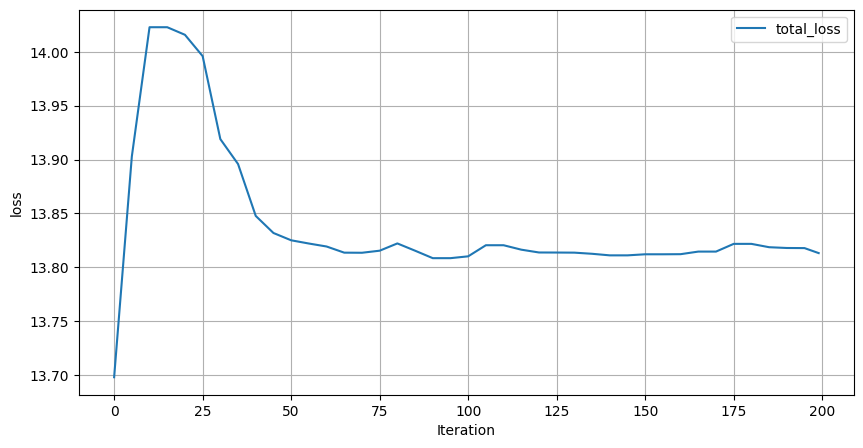

In [5]:
plt.figure(figsize=(10,5))
plt.plot(metrics['iteration'], metrics['total_loss'], label='total_loss')
# plt.xlim(0, 3000)
plt.xlabel('Iteration')
plt.ylabel('loss')
plt.grid(True)
plt.legend()
plt.show()

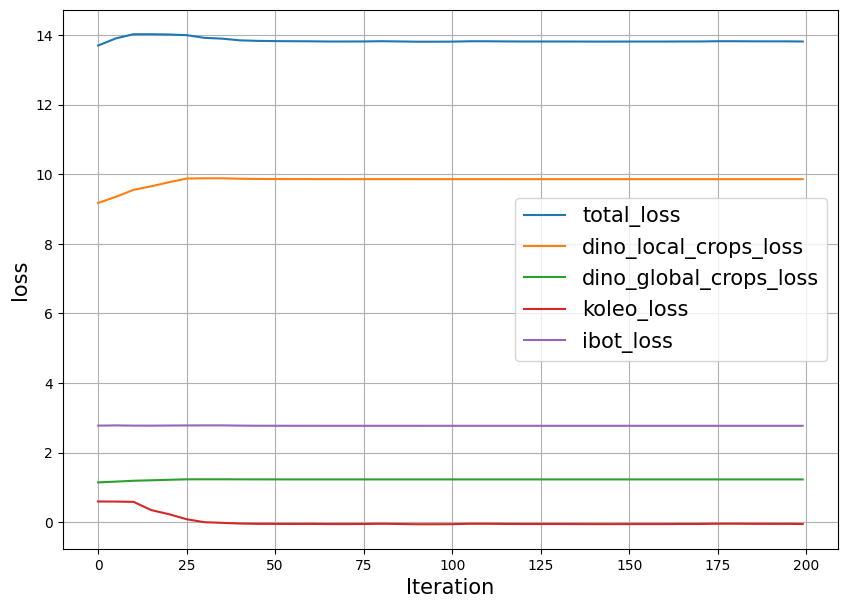

In [6]:
plt.figure(figsize=(10,7))
for k in losses_keys:
    plt.plot(metrics['iteration'], metrics[k], label=k)
plt.xlabel('Iteration', fontsize=15)
plt.ylabel('loss', fontsize=15)
plt.grid(True)
plt.legend(fontsize=15)
plt.show()

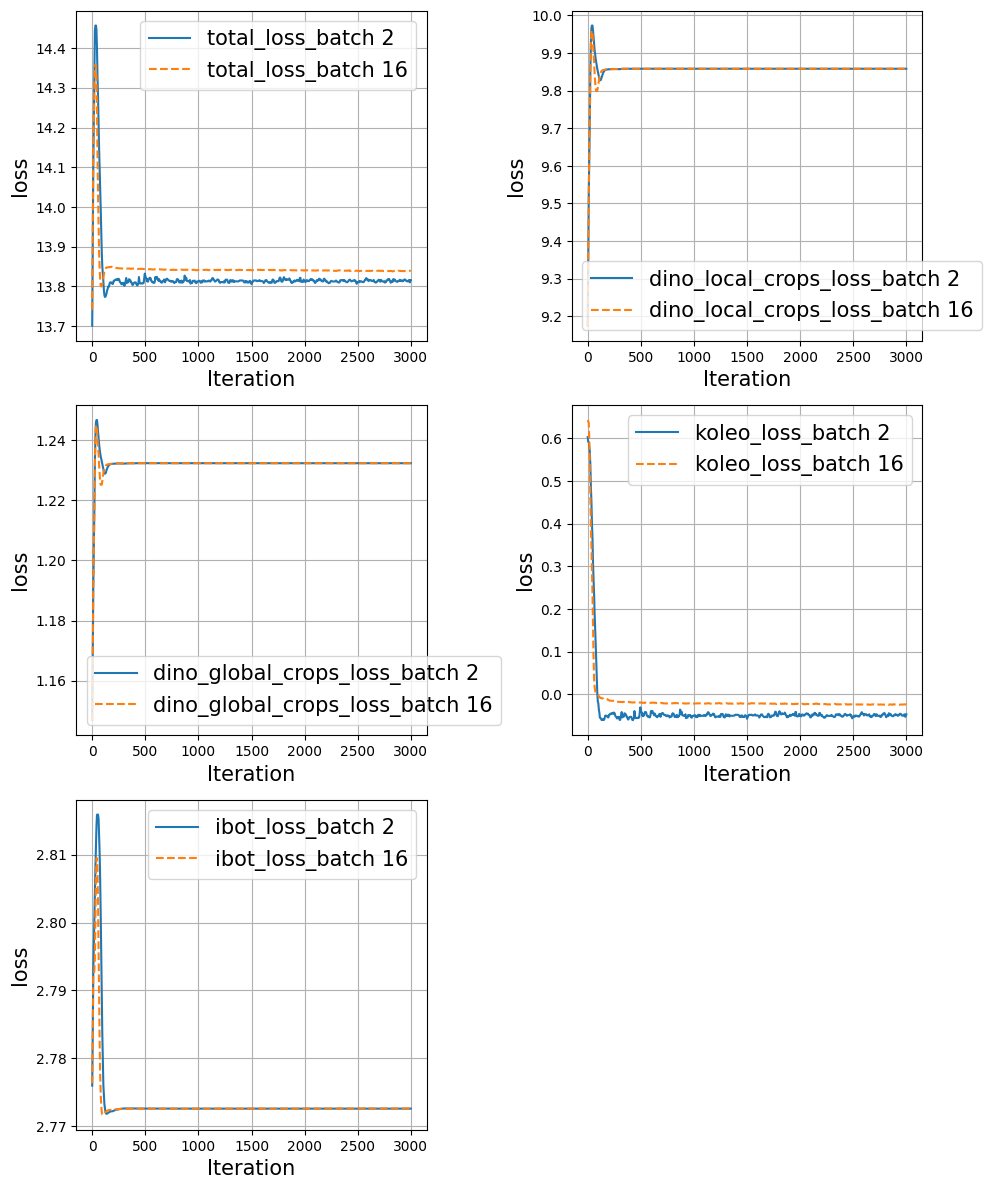

In [15]:
# fig, axes = plt.subplots(5,1, figsize=(5,4*5))

# for i, k in enumerate(losses_keys):
#     axes[i].plot(metrics['iteration'], metrics[k], label=k)
#     axes[i].set_xlabel('Iteration', fontsize=15)
#     axes[i].set_ylabel('loss', fontsize=15)
#     axes[i].grid(True)
#     axes[i].legend(fontsize=15)
# plt.show()
fig, axes = plt.subplots(3, 2, figsize=(5*2, 4*3))

for i, k in enumerate(losses_keys):
    if i < 6:  # Only plot first 6 losses (3x2 = 6 subplots)
        row = i // 2  # Calculate row index
        col = i % 2   # Calculate column index
        axes[row, col].plot(metrics['iteration'], metrics[k], label=k+'_batch 2')
        axes[row, col].plot(metrics_batch16['iteration'], metrics_batch16[k], label=k+'_batch 16', linestyle='--')
        axes[row, col].set_xlabel('Iteration', fontsize=15)
        axes[row, col].set_ylabel('loss', fontsize=15)
        axes[row, col].grid(True)
        axes[row, col].legend(fontsize=15)

# Hide empty subplots if you have fewer than 6 losses
for i in range(len(losses_keys), 6):
    row = i // 2
    col = i % 2
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

### Peak memory usage vs iteration

In [12]:
import json
with open('eval_mem_runtime.json', 'r') as f:
    data = json.load(f)
# with open('/nfs/data/1/rrazakami/work/dinov2ForLArTPC/out_cvn_memlite_batchpergpu_16/eval_mem_runtime.json', 'r') as f:
#     data_batch16 = json.load(f)

In [13]:
data.keys()

dict_keys(['runtime', 'peak_memory', 'total_training_time_s'])

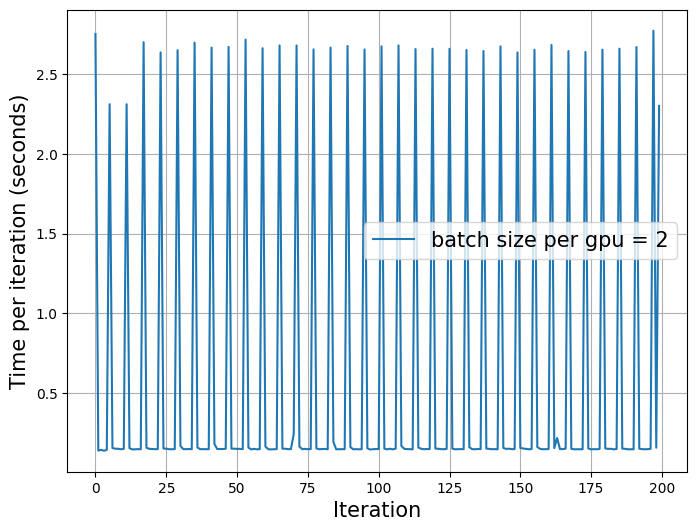

Total runtime of all iterations : 1.95 minutes


In [15]:
plt.figure(figsize=(8,6))
plt.plot(data['runtime']['iteration'], np.array(data['runtime']['time_per_iteration_s']), label='batch size per gpu = 2')
# plt.plot(data_batch16['runtime']['iteration'], np.array(data_batch16['runtime']['time_per_iteration_s']), label='batch size per gpu = 16')
# plt.xlim(0,100)
# plt.ylim(0.1,0.2)
plt.xlabel('Iteration', fontsize=15)
# plt.yscale('log')
plt.ylabel('Time per iteration (seconds)', fontsize=15)
# plt.title('MY BENCHMARKING DINO v2')
plt.legend(fontsize=15)
plt.grid(True)
plt.show()
print(f'Total runtime of all iterations : {np.sum(np.array(data["runtime"]["time_per_iteration_s"]))/60:.2f} minutes')

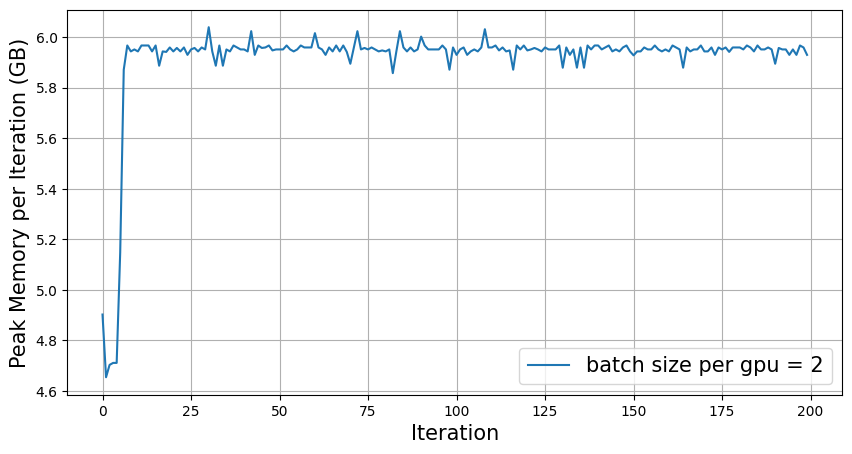

In [17]:
plt.figure(figsize=(10,5))
plt.plot(data['peak_memory']['iteration'], np.array(data['peak_memory']['peak_memory_GB']), label='batch size per gpu = 2')
# plt.plot(data_batch16['peak_memory']['iteration'], np.array(data_batch16['peak_memory']['peak_memory_GB']), label='batch size per gpu = 16')
# plt.xlim(0,100)
plt.xlabel('Iteration', fontsize=15)
plt.ylabel('Peak Memory per Iteration (GB)', fontsize=15)
plt.legend(fontsize=15)
plt.grid(True)
plt.show()

In [144]:
data['total_training_time_s']/60

8.910728120803833